**importing libraries**

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

**IMPORTING & READING DATA**

In [4]:
path="/content/drive/MyDrive/intership/data.csv"
df= pd.read_csv(path  ,encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


**Data Preprocessing**

In [5]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [6]:
df = df.dropna(subset=['CustomerID'])

In [7]:
df = df.copy()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df[['Quantity','UnitPrice','TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


count RFM

In [8]:
reference_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,2,0.00
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [ ]:
sc = StandardScaler()
rfm_scaled = sc.fit_transform(rfm)

print(rfm_scaled)

[[ 2.32202285 -0.32936215 -0.23100099]
 [-0.89373323  0.20610242  0.29343167]
 [-0.1691956  -0.11517632 -0.01231622]
 ...
 [-0.83418219 -0.22226923 -0.20951263]
 [-0.87388289  1.16993863  0.02390005]
 [-0.48680114 -0.22226923 -0.00744423]]


In [ ]:
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

print("Selected Components Explained Variance:", pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))

Selected Components Explained Variance: [0.55994858 0.30067157]
Total Variance Retained: 0.8606201523379673


In [11]:
X = df[['Quantity', 'UnitPrice']]

kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

df['Customer_Type'] = df['Cluster'].map({
    0: 'Regular',
    1: 'VIP'
})

print(df[['Quantity', 'UnitPrice', 'Customer_Type']].head())

   Quantity  UnitPrice Customer_Type
0         6       2.55       Regular
1         6       3.39       Regular
2         8       2.75       Regular
3         6       3.39       Regular
4         6       3.39       Regular


k means

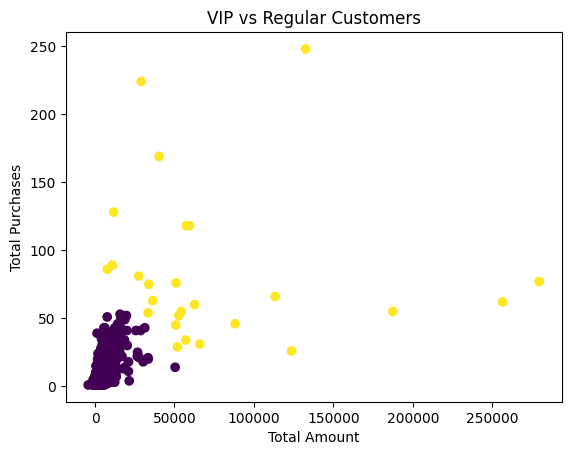

In [16]:
plt.scatter(customer_data['TotalAmount'],
            customer_data['TotalPurchases'],
            c=customer_data['Cluster'])

plt.xlabel("Total Amount")
plt.ylabel("Total Purchases")
plt.title("VIP vs Regular Customers")
plt.show()